In [10]:
from google.colab import files
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:

uploaded = files.upload()
filename = next(iter(uploaded))
print("Uploaded: ", filename)

img_clean = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

#bug check artifact, image i had could not be read earlier
assert img_clean is not None, "Could not read the image"

print("Shape:", img_clean.shape, "| dtype:", img_clean.dtype)

Saving Daraga_Church,_Daraga_Albay,_the_Philippines.jpg to Daraga_Church,_Daraga_Albay,_the_Philippines (1).jpg
Uploaded:  Daraga_Church,_Daraga_Albay,_the_Philippines (1).jpg
Shape: (563, 750) | dtype: uint8


In [12]:
def compute_mse(original, test):
    diff = original.astype(np.float64) - test.astype(np.float64)
    return float(np.mean(diff ** 2))

def compute_psnr(original, test, max_pixel=255.0):
    mse = compute_mse(original, test)
    if mse == 0:
        return float("inf")
    return 10 * np.log10((max_pixel ** 2) / mse)

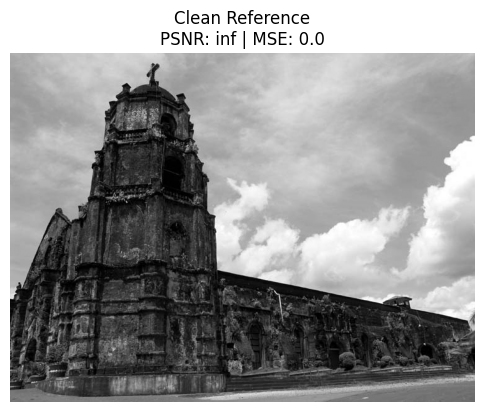

 Shape: (563, 750)
 Dtype: uint8
   Min: 0
   Max: 255
  Mean: 126.41
   Std: 74.19
   MSE: 0.0
  PSNR: inf


{'Shape': (563, 750),
 'Dtype': dtype('uint8'),
 'Min': 0,
 'Max': 255,
 'Mean': 126.41,
 'Std': 74.19,
 'MSE': 0.0,
 'PSNR': 'inf'}

In [13]:
def show_image_stats(img, title = "Image", reference = None):
    stats = {
        "Shape": img.shape,
        "Dtype": img.dtype,
        "Min": int(img.min()),
        "Max": int(img.max()),
        "Mean": round(float(img.mean()), 2),
        "Std": round(float(img.std()), 2),
    }

    if reference is not None:
        mse = compute_mse(reference, img)
        psnr = compute_psnr(reference, img)
        stats["MSE"] = round(mse, 2)
        stats["PSNR"] = "inf" if np.isinf(psnr) else f"{psnr:.2f} dB"
        title = f"{title}\nPSNR: {stats['PSNR']} | MSE: {stats['MSE']}"

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()

    for k, v in stats.items():
        print(f"{k:>6}: {v}")

    return stats

show_image_stats(img_clean, "Clean Reference", reference=img_clean)

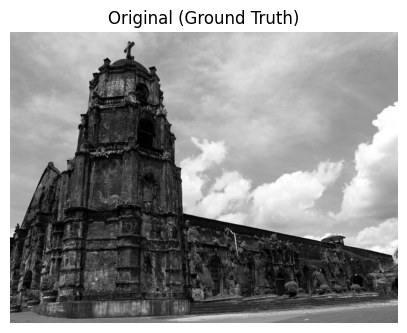

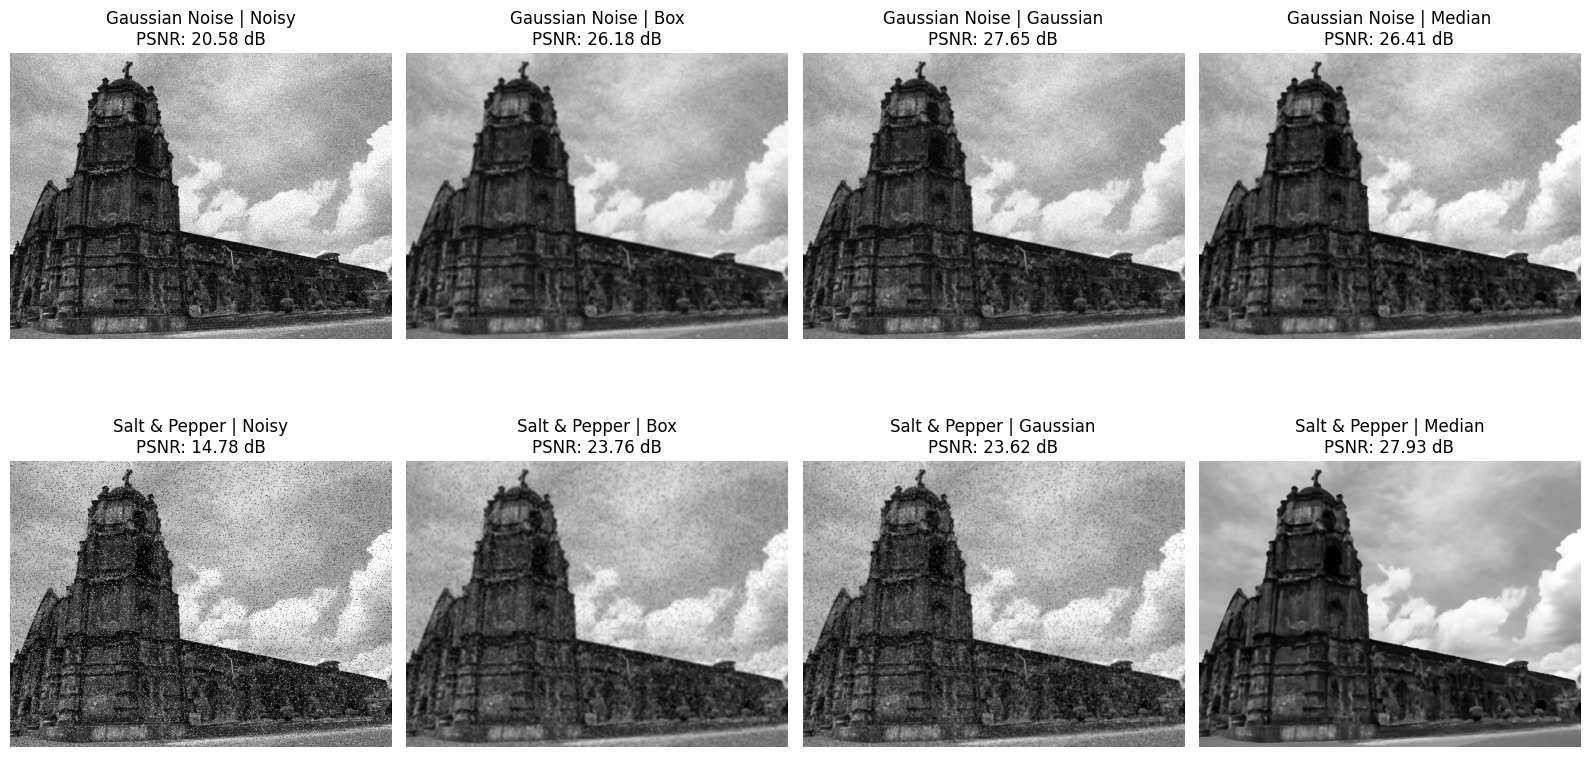

,Noise,Filter,MSE,PSNR (dB)
0,Gaussian Noise,Noisy,568.42,20.58
1,Gaussian Noise,Box,156.59,26.18
2,Gaussian Noise,Gaussian,111.58,27.65
3,Gaussian Noise,Median,148.64,26.41
4,Salt & Pepper,Noisy,2165.50,14.78
5,Salt & Pepper,Box,273.33,23.76
6,Salt & Pepper,Gaussian,282.33,23.62
7,Salt & Pepper,Median,104.84,27.93


In [14]:
np.random.seed(67)

#noises
gaussian_noise = np.random.normal(0, 25, img_clean.shape)
img_gaussian = np.clip(img_clean.astype(np.float32) + gaussian_noise, 0, 255).astype(np.uint8)

img_saltpepper = img_clean.copy()
mask = np.random.rand(*img_clean.shape)
img_saltpepper[mask < 0.05] = 0 #pepper at 2.5%
img_saltpepper[mask > 0.95] = 255 #salt at 2.5%

#Filters 5x5
noisy = {"Gaussian Noise": img_gaussian, "Salt & Pepper": img_saltpepper}
results, rows = {}, []
for name, img in noisy.items():
    results[name] = {
        "Noisy": img,
        "Box": cv2.blur(img, (5, 5)),
        "Gaussian": cv2.GaussianBlur(img, (5, 5), 0),
        "Median": cv2.medianBlur(img, 5),
    }
    for f, out in results[name].items():
        rows.append([name, f, compute_mse(img_clean, out), compute_psnr(img_clean, out)])


#display

#original
plt.figure(figsize=(5, 5))
plt.imshow(img_clean, cmap="gray", vmin=0, vmax=255)
plt.title("Original (Ground Truth)")
plt.axis("off")
plt.show()

#modified
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for r, (name, outs) in enumerate(results.items()):
    for c, (f, out) in enumerate(outs.items()):
        axes[r, c].imshow(out, cmap="gray", vmin=0, vmax=255)
        axes[r, c].set_title(f"{name} | {f}\nPSNR: {compute_psnr(img_clean, out):.2f} dB")
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()


#stats table
display(pd.DataFrame(rows, columns=["Noise", "Filter", "MSE", "PSNR (dB)"]).round(2))



# Guide Question 1 Answer

The median filter clearly outperforms Gaussian on slat pepper noise (around 2.7 times less error), through one core property, how they treat outliers. Gaussian smoothing is a linear weighted average, that means each pixel in the 5x5 window will contribute to the output, even the corrupted ones. Since salt and pepper pixels are extrema, 0 or 255, this severely hampers the collective property of gaussian, which is qhy speckles remain in the sky and the church has visible white dots. The median filter is based on order statistics instead: it sorts the 25 values in the window and picks the middle one. Because impulses are always extreme, sorting pushes them to the ends of the list where they have no influence, and the output stays a real, uncorrupted pixel value from the neighborhood. At 5% noise, each window will only hold around one impulse per slide, far from the 13 needed to usurp the median, so impulses are rejected almost everytime. Notably, the advanatage of Gaussian lies in the reverse of Gaussian noise, since that noise has no outliers and averages much better.


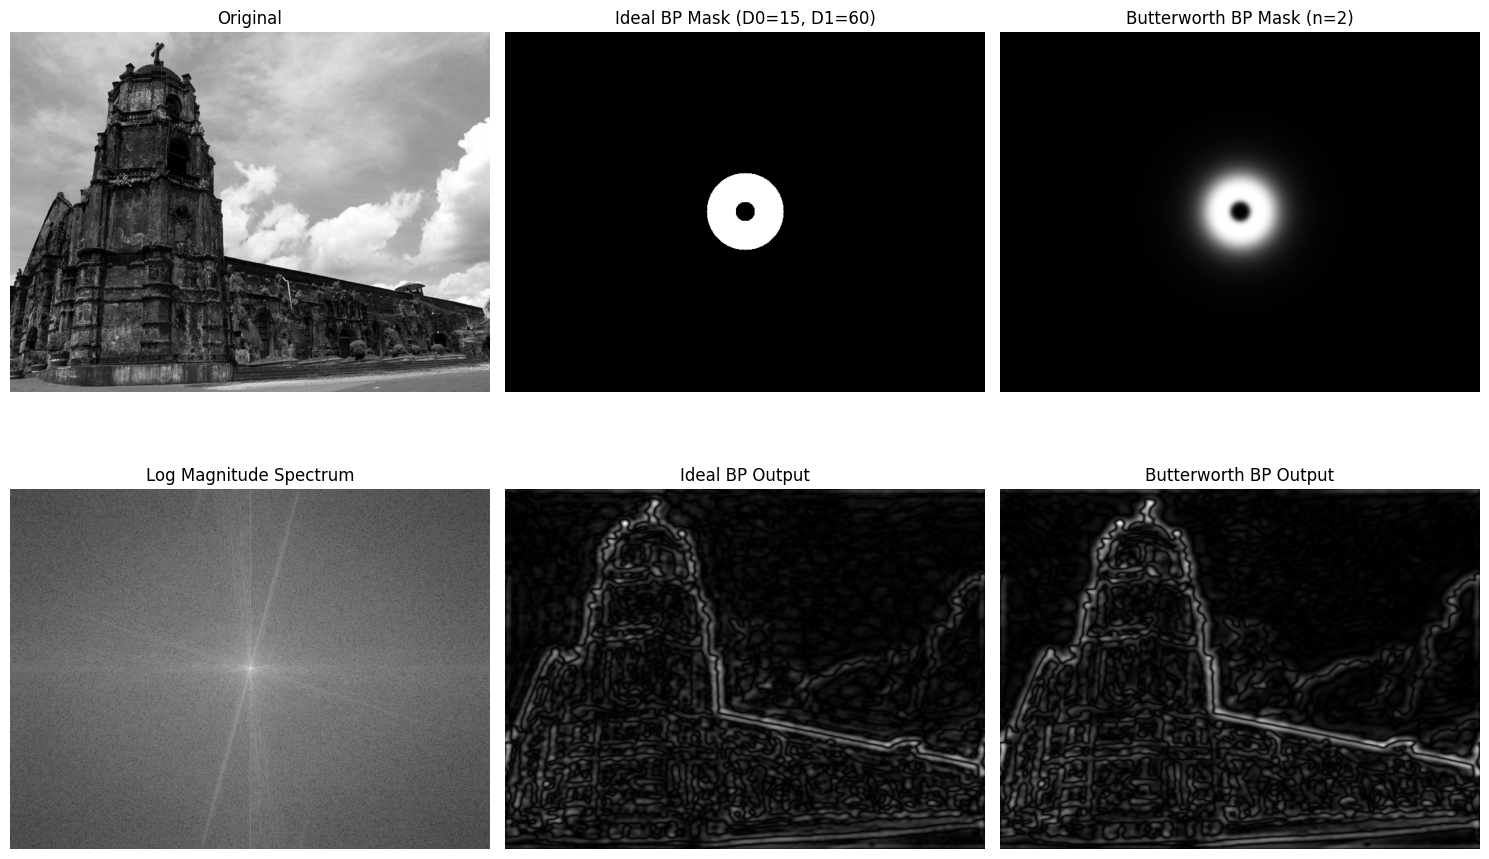

In [15]:
#DFT

img = img_clean
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)


rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

#ditance grid
y, x = np.ogrid[-crow:rows - crow, -ccol:cols - ccol]
D = np.sqrt(x**2 + y**2)

D0, D1, n = 15, 60, 2

#ideal band pass mask
H_ideal = ((D >= D0) & (D <= D1)).astype(np.float32)
mask_ideal = np.dstack([H_ideal, H_ideal])

#buttterworth band pass mask
W = D1 - D0 # band width = 45
C = np.sqrt(D0 * D1) # band center = 30, gives H = 0.5 exactly at D0 and D1
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = (D * W) / (D**2 - C**2)
H_butter = (1 - 1 / (1 + ratio**(2 * n))).astype(np.float32)
H_butter = np.nan_to_num(H_butter, nan=1.0)   # D = C gives H = 1
mask_butter = np.dstack([H_butter, H_butter])


def apply_mask(mask):
    f_ishift = np.fft.ifftshift(dft_shift * mask)
    img_back = cv2.idft(f_ishift)
    mag = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
    return np.clip(cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX), 0, 255).astype(np.uint8)

out_ideal = apply_mask(mask_ideal)
out_butter = apply_mask(mask_butter)

#display
spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

panels = [
    (img, "Original"),
    (H_ideal, f"Ideal BP Mask (D0={D0}, D1={D1})"),
    (H_butter, f"Butterworth BP Mask (n={n})"),
    (spectrum, "Log Magnitude Spectrum"),
    (out_ideal, "Ideal BP Output"),
    (out_butter, "Butterworth BP Output"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (im, title) in zip(axes.flat, panels):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Guide Question 2

Both filters keep only the mid range frequencies between radii 15 and 60, so both outputs actually just look like edge maps. The low frequencies that carry smooth brightness and overall tone of the sky are removed, and the finest detail above the given radius of 60 is removed, leaving the tower outline, roofline, and some wall texture. The ideal output has a salt-and-pepper-like mottled wavy texture spread across flat regions like the sky, and its edges are surrounded by faint parallel lines, while butterworth does look very similar though a bit calmer with cleaner darker regions. A mask that jumps abruptly from 0 to 1 transforms into a sinc-like kernel (for a circular ring, a difference of two Bessel-based "jinc" functions) with a central peak surrounded by oscillating side lobes that decay very slowly. When a kernel is convolved with a high contrast edge, each side lobe leaves a copy of the edge with a small offset, producing the rippled boundaries observed. Gibbs Phenomenon: truncating a frequency representation abruptly causes overshoot on discontinuities that never disappears, it only shifts closer to the edge as the band changes. The butterworth filter avoids this since its mask rolls off smoothly around the cutoffs instead of jumping, so the spatial kernel has weak side lobes and the edges are constructed without overly visible rings. At order n = 2, the change is gentle enough that the ringing is negligible, though raising the order would sharpen the cutoff toward the ideal filter and gradually give the ring back.

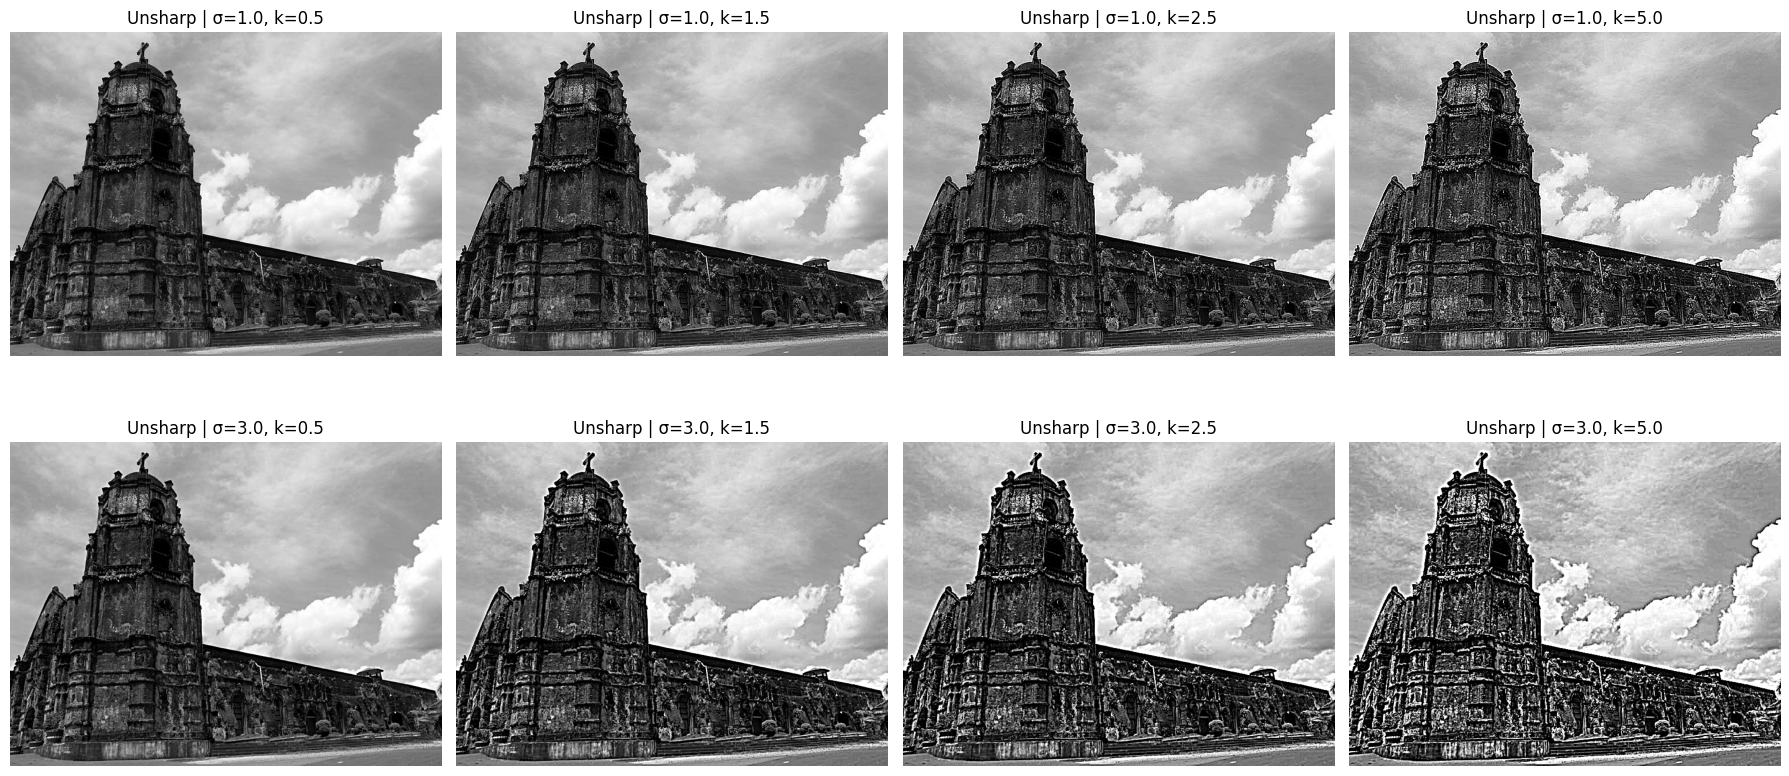

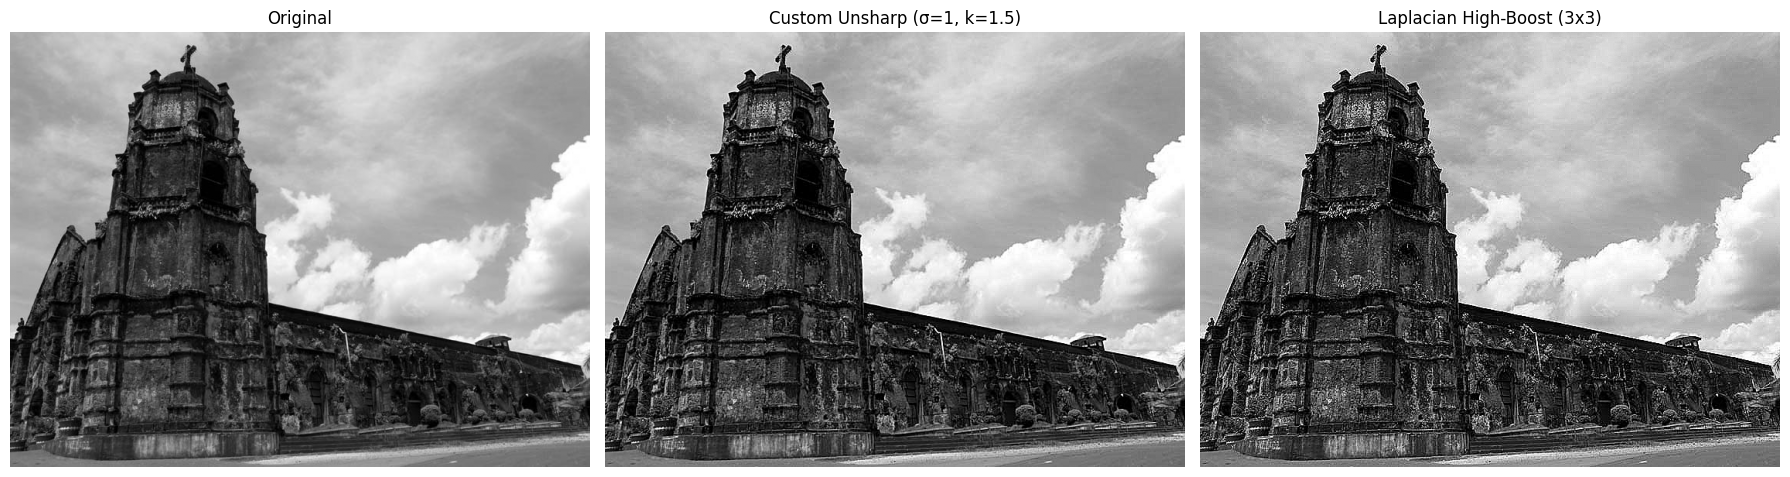

,Image,Flat region std,Edge region std
0,Original,0.70,103.830002
1,"Unsharp σ=1, k=0.5",0.97,105.949997
2,"Unsharp σ=1, k=1.5",1.02,107.980003
3,"Unsharp σ=1, k=2.5",1.23,109.160004
4,"Unsharp σ=1, k=5.0",1.78,111.080002
5,Laplacian High-Boost,1.31,108.629997


In [16]:
def unsharp_mask(image, kernel_size = (5,5), sigma = 1.0, k = 1.5):
    img_f = image.astype(np.float32)
    blurred = cv2.GaussianBlur(img_f, kernel_size, sigma)   # f_smooth
    mask = img_f - blurred                                   # g(x, y)
    sharpened = img_f + k * mask                             # f + k * g
    return np.clip(sharpened, 0, 255).astype(np.uint8)

img = img_clean


#laplacian high-boost via direct convolution
lap_kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]], dtype=np.float32)
lap_out = np.clip(cv2.filter2D(img.astype(np.float32), -1, lap_kernel), 0, 255).astype(np.uint8)

#quick sweep of sigma and k

sigmas = [1.0, 3.0]
ks = [0.5, 1.5, 2.5, 5.0]
outputs = {}
for s in sigmas:
    ksize = int(6 * s) | 1 # odd kernel covering about ±3 sigma
    for k in ks:
        outputs[(s, k)] = unsharp_mask(img, (ksize, ksize), s, k)

fig, axes = plt.subplots(len(sigmas), len(ks), figsize=(18, 9))
for r, s in enumerate(sigmas):
    for c, k in enumerate(ks):
        axes[r, c].imshow(outputs[(s, k)], cmap="gray", vmin=0, vmax=255)
        axes[r, c].set_title(f"Unsharp | σ={s}, k={k}")
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()


#unsharp vs lapalacian highboost plot comparisons
compare = [(img, "Original"), (outputs[(1.0, 1.5)], "Custom Unsharp (σ=1, k=1.5)"), (lap_out, "Laplacian High-Boost (3x3)")]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (im, title) in zip(axes, compare):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


#5 STD in flat region vs edge region comparison
P = 32  # patch size
f = img.astype(np.float32)
local_std = np.sqrt(np.maximum(cv2.blur(f**2, (P, P)) - cv2.blur(f, (P, P))**2, 0))
local_std[:P, :] = local_std[-P:, :] = local_std[:, :P] = local_std[:, -P:] = np.nan
fy, fx = np.unravel_index(np.nanargmin(local_std), local_std.shape)   # flattest patch
ey, ex = np.unravel_index(np.nanargmax(local_std), local_std.shape)   # busiest edge patch
patch = lambda im, y, x: im[y - P//2:y + P//2, x - P//2:x + P//2].astype(np.float32)

rows = [["Original", patch(img, fy, fx).std(), patch(img, ey, ex).std()]]
for k in ks:
    out = outputs[(1.0, k)]
    rows.append([f"Unsharp σ=1, k={k}", patch(out, fy, fx).std(), patch(out, ey, ex).std()])
rows.append(["Laplacian High-Boost", patch(lap_out, fy, fx).std(), patch(lap_out, ey, ex).std()])

display(pd.DataFrame(rows, columns=["Image", "Flat region std", "Edge region std"]).round(2))

# Guide Question 3
When the high boost factor is set beyond 2, the sharpening turns into very evident artifacts. In k = 5.0 (highest k I used in my tests)  outputs were filled with bright white halos along high contrast boundaries, most clearly around cloud edges on the right and the outline of the church. Moreover, the stone walls take on a harsh texture, it looks incredibly overprocessed as opposed to detailed. This happens because unsharp masking finds the difference between the original image and its blurred version then adds it back. Near an edge, that difference is very noticeable, further multiplied by larger k’s pushes the extremes even further. Many of these pixels hit the 255 or 0 limit then get clipped, which is why the effects on high k look flat and blown out. The effect gets worse at SD = 3, since the wider blur make the halos even thicker. The standard deviation measurements of the images show how differently the two kinds of regions respond. In the flat region the SD went from 0.70 in the original to 1.78 at k = 5.0, a 2.5 times increase, but since the region started almost perfectly uniform anyways, it stays below 2 and appears flat to the eye. The increase comes from the noise and texture being amplified even further, which creates a similar visible grain across all high k variations. In the edge region, the SD rose a bit less 103.83 to 111.08, relatively small compared to the flat regions, as the dark and bright sides of the boundary stretched further apart. In short, unsharp masking concentrates the effects on edges while leaving flat areas visually similar at moderate k, but at high k it amplifies both noise in smooth areas and saturated edges. As a comparison, the 3x3 Laplacian high boost result behaved similar to the custom filter between k = 1.5 and k = 2.5, looking like a crispier image, but not too much.